# 世界地震カタログの記述分析

run_id: `v020-exp-38`。Kaggle公開データの規模・深さ・地域・時間を分析し、収録基準と検出限界を明示する。短期予知や因果推論は行わない。実行はJupyter MCPのみ。認証情報は保存・表示しない。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, contextlib, io, inspect, re
from datetime import datetime, timezone, timedelta
from dataclasses import asdict
import nbformat
repo = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(repo / 'src'))
from ai_data_scientist import project_manager as pm, lifecycle, language_router
RUN_ID = 'v020-exp-38'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-38-earthquakes', projects_root=repo / 'benchmark/projects')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
print('指示言語:', language_router.detect_language('世界地震データを日本語で分析してください。'))
phase_log = []
@contextlib.contextmanager
def phase(kind, label):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検出')
    start = lifecycle.mark_execution_start if kind == 'execution' else lifecycle.mark_write_start
    end = lifecycle.mark_execution_end if kind == 'execution' else lifecycle.mark_write_end
    start(RUN_ID)
    phase_log.append({'phase': kind, 'label': label, 'event': 'start', 'at': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': kind, 'label': label, 'event': 'end', 'at': datetime.now(timezone.utc).isoformat()})
def write_nb(mutation):
    with phase('write', 'Notebook永続化'):
        return pm.enqueue_write(handle, mutation)
print('Notebook:', str(handle.notebook_path))
print('run_id:', RUN_ID)


指示言語: ja
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-38-earthquakes/notebooks/kaggle-v020-kaggle-exp-38-earthquakes.ipynb
run_id: v020-exp-38


## 公開カタログ検索と取得根拠
取得できない場合に限り指定white-paperを調べ、同じデータセットと明記されたCSV以外は利用しない。

互換性記録: インストール済みKaggle SDKにdataset_viewは存在しなかったため、公開説明はdataset_metadataで取得する。Kaggle SDK固有のAPI差異でありJupytermind不具合ではない。

In [2]:
retrieval = {'status': 'searching', 'searched_at_utc': datetime.now(timezone.utc).isoformat(), 'query': 'global earthquakes'}
api = None
with phase('execution', 'Kaggle認証・公開カタログ検索'):
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            datasets = api.dataset_list(search='global earthquakes')
        candidates = [{'slug': d.ref, 'title': d.title, 'size': getattr(d, 'total_bytes', None)} for d in datasets]
        retrieval['candidates'] = candidates
        retrieval['status'] = 'search_ok'
        print(json.dumps(candidates, ensure_ascii=False, indent=2))
    except Exception as exc:
        retrieval['status'] = 'kaggle_failed'
        retrieval['error_type'] = type(exc).__name__
        print('Kaggle検索失敗（認証情報・例外本文は非表示）:', type(exc).__name__)
if retrieval['status'] == 'kaggle_failed':
    paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
    retrieval['fallback_paper_exists'] = paper.exists()
    print('指定white-paperの存在:', paper.exists())
    if paper.exists():
        text = paper.read_text(encoding='utf-8')
        lines = text.splitlines()
        matches = [i for i, line in enumerate(lines) if re.search(r'earthquake|地震|exp-38', line, re.I)]
        for i in matches[:12]:
            print('\n'.join(lines[max(0, i-3):i+7]))


[
  {
    "slug": "mustafakeser4/earthquakes-2023-global",
    "title": "Earthquakes 2023 Global",
    "size": 1530778
  },
  {
    "slug": "zaneneave/global-earthquakes-2020-2026",
    "title": "Global Earthquakes 2020-2026",
    "size": 607012
  },
  {
    "slug": "dhrubangtalukdar/200-years-of-global-major-earthquakes-18262026",
    "title": "200 Years of Global Major Earthquakes (1826–2026)",
    "size": 4733856
  },
  {
    "slug": "ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset",
    "title": "Global Earthquake-Tsunami Risk Assessment Dataset",
    "size": 16151
  },
  {
    "slug": "usgs/earthquake-database",
    "title": "Significant Earthquakes, 1965-2016",
    "size": 604367
  },
  {
    "slug": "shreyasur965/recent-earthquakes",
    "title": "Global Earthquake Data",
    "size": 219182
  },
  {
    "slug": "alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023",
    "title": "All the Earthquakes Dataset : from 1990-2023",
    "size": 121537542
  },
 

In [3]:
SLUG = 'usgs/earthquake-database'
FILE_NAME = 'database.csv'
retrieval['selection_reason'] = '検索結果に実在するUSGS所有の長期世界カタログ。提供者が明示され、規模・深さ・座標・時刻を含む。小規模地震を網羅するカタログではない。'
with phase('execution', 'ファイル一覧・Kaggleダウンロード'):
    if retrieval['status'] != 'search_ok':
        raise RuntimeError('Kaggle検索失敗。対応する公開CSVの明記を確認するまで分析しない。')
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            files = api.dataset_list_files(SLUG)
            api.dataset_metadata(SLUG, path=str(data_dir))
        file_list = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in files.files]
        print('公開ファイル一覧:', json.dumps(file_list, ensure_ascii=False))
        if FILE_NAME not in [f['name'] for f in file_list]:
            raise FileNotFoundError('期待した公開CSVが一覧にない')
        metadata = json.loads((data_dir / 'dataset-metadata.json').read_text(encoding='utf-8'))
        description = metadata.get('info', metadata).get('description', '')
        retrieval['source_description'] = description
        retrieval['dataset_version'] = next(d.current_version_number for d in datasets if d.ref == SLUG)
        retrieval['source_url'] = 'https://www.kaggle.com/datasets/' + SLUG
        print('Kaggleデータ説明:', description)
        print('バージョン:', retrieval['dataset_version'])
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(SLUG, FILE_NAME, path=str(data_dir), force=True, quiet=True)
        csv_path = data_dir / FILE_NAME
        zip_path = data_dir / (FILE_NAME + '.zip')
        if zip_path.exists():
            import zipfile
            with zipfile.ZipFile(zip_path) as archive:
                if FILE_NAME not in archive.namelist():
                    raise FileNotFoundError('ZIP内のCSVが一致しない')
                csv_path.write_bytes(archive.read(FILE_NAME))
        if not csv_path.exists():
            raise FileNotFoundError('取得CSVが見つからない')
        expected_sha256 = '691ff3ab40c1a5c25fb14dd23f92f14c71cd57cb673a5b5b484d4a5fe0866e03'
        if hashlib.sha256(csv_path.read_bytes()).hexdigest() != expected_sha256:
            raise ValueError('公開ファイルのSHA256が分析時の版と異なる')
        retrieval.update({'status': 'downloaded', 'slug': SLUG, 'filename': FILE_NAME, 'acquired_at_utc': datetime.now(timezone.utc).isoformat(), 'acquired_at_jst': datetime.now(timezone(timedelta(hours=9))).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'bytes': csv_path.stat().st_size})
        print('取得manifest:', json.dumps(retrieval, ensure_ascii=False, indent=2))
    except Exception as exc:
        retrieval.update({'status': 'download_failed', 'error_type': type(exc).__name__})
        print('取得失敗:', type(exc).__name__, '（秘密保護のため例外本文は非表示）')
        paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        print('指定white-paperの存在:', paper.exists())
        if paper.exists():
            lines = paper.read_text(encoding='utf-8').splitlines()
            for i, line in enumerate(lines):
                if SLUG in line or 'exp-38' in line or '地震' in line:
                    print('\n'.join(lines[max(0, i-3):i+8]))


公開ファイル一覧: [{"name": "database.csv", "bytes": 2397103}]
Kaggleデータ説明: ### Context 

The National Earthquake Information Center (NEIC) determines the location and size of all significant earthquakes that occur worldwide and disseminates this information immediately to national and international agencies, scientists, critical facilities, and the general public. The NEIC compiles and provides to scientists and to the public an extensive seismic database that serves as a foundation for scientific research through the operation of modern digital national and global seismograph networks and cooperative international agreements. The NEIC is the national data center and archive for earthquake information.


### Content

This dataset includes a record of the date, time, location, depth, magnitude, and source of every earthquake with a reported magnitude 5.5 or higher since 1965.

#[Start a new kernel][1]


  [1]: https://www.kaggle.com/usgs/earthquake-database/kernels?modal=true
バージョン: 1
取得manife

In [4]:
import pandas as pd
import numpy as np
from IPython.display import display
from ai_data_scientist import ingestion, eda, cleaning, data_quality, data_definition, analysis_assumptions, sensitivity, visualization, notebook_audit
with phase('execution', 'CSV読込と初期探索'):
    if retrieval['status'] != 'downloaded':
        raise RuntimeError('対応データの取得に失敗。分析を中止。')
    loaded = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(csv_path)), row_limit=100000)
    raw = loaded.dataframe
    print('読込:', loaded.row_count, '行', loaded.column_count, '列; truncated=', loaded.truncated)
    print('列:', list(raw.columns))
    display(raw.head(3))
    print('欠損件数:', raw.isna().sum().to_dict())
    eda_result = eda.explore(raw)
    print('EDA要約（全内容はEDA manifestとして保存）:', str(eda_result)[:2500])


読込: 23412 行 21 列; truncated= False
列: ['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error', 'Depth Seismic Stations', 'Magnitude', 'Magnitude Type', 'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID', 'Source', 'Location Source', 'Magnitude Source', 'Status']
欠損件数: {'Date': 0, 'Time': 0, 'Latitude': 0, 'Longitude': 0, 'Type': 0, 'Depth': 0, 'Depth Error': 18951, 'Depth Seismic Stations': 16315, 'Magnitude': 0, 'Magnitude Type': 3, 'Magnitude Error': 23085, 'Magnitude Seismic Stations': 20848, 'Azimuthal Gap': 16113, 'Horizontal Distance': 21808, 'Horizontal Error': 22256, 'Root Mean Square': 6060, 'ID': 0, 'Source': 0, 'Location Source': 0, 'Magnitude Source': 0, 'Status': 0}
EDA要約（全内容はEDA manifestとして保存）: EDAReport(describe={'Latitude': {'count': 23412.0, 'mean': 1.6790331197719117, 'std': 30.113182898720652, 'min': -77.08, '25%': -18.653, '50%': -3.5685000000000002, '75%': 26.19075, 

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic


## データ定義と品質・分析範囲
M5.5はカタログの収録条件であり、観測網の物理的検出限界や全地域・全年の完全性ではない。記録の端点は地震の発生端点であり、観測開始・終了を厳密に証明しない。

In [5]:
import requests
from html import unescape
reference_specs = {
    'usgs_terms': 'https://earthquake.usgs.gov/data/comcat/data-eventterms.php',
    'usgs_csv': 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php',
    'usgs_completeness': 'https://www.usgs.gov/programs/earthquake-hazards/lists-maps-and-statistics',
    'usgs_prediction': 'https://www.usgs.gov/faqs/can-you-predict-earthquakes'
}
references = {}
with phase('execution', '公開データ定義・検出限界の文書確認'):
    for key, url in reference_specs.items():
        dest = data_dir / (key + '.html')
        if not dest.exists():
            response = requests.get(url, timeout=45)
            response.raise_for_status()
            dest.write_text(response.text, encoding='utf-8')
        html = dest.read_text(encoding='utf-8')
        plain = unescape(re.sub('<[^>]+>', ' ', html))
        plain = re.sub(r'\s+', ' ', plain)
        needles = {'usgs_terms':['kilometers', 'UTC', 'negative', 'fixed', '33'], 'usgs_csv':['depth', 'time', 'mag'], 'usgs_completeness':['detect', '1900', 'earthquakes'], 'usgs_prediction':['No.', 'predict', 'probabilities']}[key]
        excerpts = []
        for needle in needles:
            position = plain.lower().find(needle.lower())
            if position >= 0:
                excerpts.append(plain[max(0, position-120):position+700])
        references[key] = {'url': url, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(dest.read_bytes()).hexdigest(), 'excerpts': excerpts}
        print(key, json.dumps(references[key], ensure_ascii=False, indent=2))


usgs_terms {
  "url": "https://earthquake.usgs.gov/data/comcat/data-eventterms.php",
  "retrieved_at_utc": "2026-10-01T22:31:00.036856+00:00",
  "sha256": "0192039a022130b78a60f6e985c1923b5a2f7b55d02e94a1c39fe73c6a1d111c",
  "excerpts": []
}
usgs_csv {
  "url": "https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php",
  "retrieved_at_utc": "2026-10-01T22:31:00.037677+00:00",
  "sha256": "44937e5c363b57005ee1bfc0db631b12f8789ee41d1edb3cd734f1b01a8baa14",
  "excerpts": [
    "for manual scientific analysis. Output Below are the fields included in the spreadsheet output: time latitude longitude depth mag magType nst gap dmin rms net id updated place type locationSource magSource horizontalError depthError magError magNst status Screenshot of the spreadsheet format, loaded into Microsoft Excel™. Feeds Past Hour Updated every minute. Significant Earthquakes M4.5+ Earthquakes M2.5+ Earthquakes M1.0+ Earthquakes All Earthquakes Past Day Updated every minute. Significant Earthquakes M4.5+ E

In [6]:
with phase('execution', '日時正規化・意味的品質検査・地震抽出'):
    working = raw.copy()
    iso_mask = working['Date'].str.contains('T', regex=False)
    combined = working['Date'] + ' ' + working['Time']
    timestamp = pd.to_datetime(combined.where(~iso_mask), format='%m/%d/%Y %H:%M:%S', errors='coerce', utc=True)
    timestamp.loc[iso_mask] = pd.to_datetime(working.loc[iso_mask, 'Date'], utc=True, errors='coerce')
    working['timestamp'] = timestamp
    print('日時ISO形式:', int(iso_mask.sum()), '件; 変換失敗:', int(timestamp.isna().sum()))
    semantic = data_quality.detect_anomalies(working, schema={
        'Latitude': {'min': -90, 'max': 90, 'not_null': True},
        'Longitude': {'min': -180, 'max': 180, 'not_null': True},
        'Magnitude': {'min': 5.5, 'max': 10, 'not_null': True},
        'Depth': {'min': 0, 'max': 750, 'not_null': True},
        'ID': {'unique': True, 'not_null': True},
        'Type': {'allowed': ['Earthquake', 'Nuclear Explosion', 'Explosion', 'Rock Burst'], 'not_null': True},
        'timestamp': {'not_null': True}
    })
    print('意味的異常:', json.dumps([asdict(x) for x in semantic], ensure_ascii=False, default=str))
    duplicate_report = cleaning.clean_dataset(working, operation='drop_duplicates')
    clean = duplicate_report.dataframe
    print('完全重複除去:', duplicate_report.rows_removed, '件;', duplicate_report.rows_before, '→', duplicate_report.rows_after)
    print('イベント内訳:', clean['Type'].value_counts().to_dict())
    eq = clean.loc[clean['Type'].eq('Earthquake')].copy()
    invalid = eq['timestamp'].isna() | eq['Magnitude'].isna() | ~eq['Latitude'].between(-90, 90) | ~eq['Longitude'].between(-180, 180)
    print('主要項目不正による除外:', int(invalid.sum()))
    eq = eq.loc[~invalid].copy()
    eq['year'] = eq['timestamp'].dt.year
    eq['month'] = eq['timestamp'].dt.month
    eq['depth_class'] = pd.cut(eq['Depth'], bins=[-np.inf,0,70,300,np.inf], labels=['負の深さ/0境界','浅発 (0,70] km','中発 (70,300] km','深発 >300 km'], right=True)
    eq.loc[eq['Depth'].eq(0), 'depth_class'] = '浅発 (0,70] km'
    eq['longitude_sector'] = pd.cut(eq['Longitude'], bins=np.arange(-180,181,60), include_lowest=True)
    print('自然地震件数:', len(eq))
    print('収録時刻範囲:', eq['timestamp'].min().isoformat(), '〜', eq['timestamp'].max().isoformat())
    print('負の深さの地震:', int(eq['Depth'].lt(0).sum()))
    display(eq.loc[eq['Depth'].lt(0), ['ID','timestamp','Depth','Magnitude']])
    display(eq[['Magnitude','Depth']].describe(percentiles=[.05,.25,.5,.75,.95]))
    display(eq['Magnitude Type'].value_counts(dropna=False).rename('件数').to_frame())


日時ISO形式: 3 件; 変換失敗: 0
意味的異常: [{"column": "Depth", "rule": "range", "row_count": 3, "message": "Column 'Depth' has 3 value(s) outside [0, 750].", "row_indices": [8099, 10977, 10978]}]
完全重複除去: 0 件; 23412 → 23412
イベント内訳: {'Earthquake': 23232, 'Nuclear Explosion': 175, 'Explosion': 4, 'Rock Burst': 1}
主要項目不正による除外: 0
自然地震件数: 23232
収録時刻範囲: 1965-01-02T13:44:18+00:00 〜 2016-12-30T20:08:28+00:00
負の深さの地震: 3


,ID,timestamp,Depth,Magnitude
8099,NC95459,1986-07-21 22:07:16+00:00,-0.076,5.60
10977,CI3031111,1992-06-28 11:57:34+00:00,-0.097,7.30
10978,CI3043549,1992-06-28 12:00:45+00:00,-1.100,5.77


,Magnitude,Depth
count,23232.000000,23232.000000
mean,5.882763,71.313913
std,0.424032,122.968384
min,5.500000,-1.100000
5%,5.500000,10.000000
25%,5.600000,15.000000
50%,5.700000,33.000000
75%,6.000000,54.800000
95%,6.700000,390.450000
max,9.100000,700.000000


,件数
Magnitude Type,
MW,7722
MWC,5668
MB,3594
MWB,2458
MWW,1983
MS,1702
ML,65
MWR,26
MD,6


In [7]:
from ai_data_scientist.data_definition import FieldValue as F
with phase('execution', 'データ定義・分析前提manifest'):
    definition = data_definition.build_manifest(
        source={'slug': F(SLUG,'verified','Kaggle API検索・ファイル一覧'), 'file': F(FILE_NAME,'verified','Kaggle API'), 'sha256': F(retrieval['sha256'],'verified','取得CSV'), 'license': F(metadata['info'].get('licenses'),'verified','dataset-metadata.json'), 'source': F('USGS/NEIC','verified','Kaggleデータ説明')},
        dataset_scope={'observed_range': F([str(eq['timestamp'].min()),str(eq['timestamp'].max())],'verified','CSV値'), 'selection_lower_magnitude': F(5.5,'verified','Kaggle Content記載・CSV最小値'), 'completeness_magnitude_by_region_year': F(None,'unknown','このCSVには観測網・未検出イベント・完全性保証がない'), 'event_scope': F('Type=Earthquakeのみ','verified','Type列を検査'), 'observation_exposure': F('1965–2016の暦年を便宜上使用','inferred','Kaggleタイトルと収録範囲; 無観測期間は判別不能')},
        variables={
            'Magnitude': {'meaning': F('地震の規模（揺れの震度ではない）','verified','Kaggle Contentのmagnitude記載'), 'unit': F('無次元対数尺度、複数のMagnitude Typeが混在','inferred','尺度は地震学上の通常解釈、方式混在はCSVで検証'), 'comparability': F('全時期・全方式で同一校正という保証なし','unknown')},
            'Depth': {'unit': F('km（USGSカタログの通常単位として採用）','inferred','この版の列辞書を直接取得できず、用語URLはGeoJSON形式ページへ遷移'), 'reference_level': F('USGS定義上の震源深さ。CSVに基準詳細なし','inferred','一般USGS定義を移し替え'), 'negative_values': F('自動削除せず感度分析対象','verified','意味的品質検査')},
            'Latitude': {'unit': F('十進度','inferred','USGSカタログ慣行と値域; この版の直接列辞書は未取得')},
            'Longitude': {'unit': F('十進度','inferred','USGSカタログ慣行と値域; この版の直接列辞書は未取得'), 'wrap': F('[-180,180]','verified','CSV値')},
            'timestamp': {'unit': F('UTC','inferred','USGS一般定義・ISO表記Z; 通常Date+TimeにTZ明記なし'), 'normalization': F('通常形式とISO3件を分岐','verified','変換失敗件数検査')},
            'longitude_sector': {'meaning': F('経度60度幅の操作的区分、国・プレートではない','verified','分析コード')}
        }, transformations=('完全重複除去','Type=Earthquake抽出','日時2形式を正規化','欠損誤差列は補完しない'))
    print('データ定義manifest:', json.dumps(asdict(definition), ensure_ascii=False, default=str, indent=2))
    print('unresolved_fields:', [(k,asdict(v)) for k,v in definition.unresolved_fields()])
    inferred = [(scope+'.'+k,asdict(v)) for scope, fields in [('dataset_scope',definition.dataset_scope)] + [('variables.'+k,v) for k,v in definition.variables.items()] for k,v in fields.items() if isinstance(v,F) and v.status == 'inferred']
    print('別途明示するinferred:', inferred)
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target':'このカタログに記録された自然地震の記述分布','predictive_scope':'なし'},
        assumptions=(
            analysis_assumptions.Assumption('selection','M5.5未満は抽出基準により含まれない','verified',conclusion_critical=True),
            analysis_assumptions.Assumption('earthquake_only','爆発・Rock Burstを分離する','tested',conclusion_critical=True),
            analysis_assumptions.Assumption('calendar_exposure','年間の観測露出は一様であると便宜的に置く','assumed',impact_if_false='年別件数を真の発生率として解釈できない',conclusion_critical=True),
            analysis_assumptions.Assumption('complete','M5.5以上の全地域・全年が完全に検出された','assumed',impact_if_false='時間変化と地域比率は観測網と収録方針に左右される',conclusion_critical=True),
            analysis_assumptions.Assumption('independence','個々の地震を独立試行とみなす','rejected',impact_if_false='余震・群発を含むため独立ポアソン誤差や通常のp値を示さない'),
            analysis_assumptions.Assumption('causal','分布から因果・短期予知を導く','rejected',impact_if_false='観測された分布は予知能力の証拠にならない')
        ), causal_scope='descriptive', sampling={'method':'カタログ全行、地震種別のみ','random_sample':False,'n':len(eq),'seed':None})
    assumption_findings = analysis_assumptions.check_manifest(assumptions)
    print('分析前提manifest:', json.dumps(asdict(assumptions), ensure_ascii=False, default=str, indent=2))
    print('前提検査の全指摘:', json.dumps([asdict(f) for f in assumption_findings], ensure_ascii=False, indent=2))
    print('独立照合データなし: validate_anomalies / compare_datasetsは適用しない。地理・深さの外れ値は真の現象の可能性があるためz-scoreで削除しない。')


データ定義manifest: {
  "source": {
    "slug": {
      "value": "usgs/earthquake-database",
      "status": "verified",
      "source": "Kaggle API検索・ファイル一覧"
    },
    "file": {
      "value": "database.csv",
      "status": "verified",
      "source": "Kaggle API"
    },
    "sha256": {
      "value": "691ff3ab40c1a5c25fb14dd23f92f14c71cd57cb673a5b5b484d4a5fe0866e03",
      "status": "verified",
      "source": "取得CSV"
    },
    "license": {
      "value": [
        {
          "name": "CC0-1.0"
        }
      ],
      "status": "verified",
      "source": "dataset-metadata.json"
    },
    "source": {
      "value": "USGS/NEIC",
      "status": "verified",
      "source": "Kaggleデータ説明"
    }
  },
  "dataset_scope": {
    "observed_range": {
      "value": [
        "1965-01-02 13:44:18+00:00",
        "2016-12-30 20:08:28+00:00"
      ],
      "status": "verified",
      "source": "CSV値"
    },
    "selection_lower_magnitude": {
      "value": 5.5,
      "status": "verified",
      "s

## 初回分析
規模・深さはヒストグラム、中央値・分位点・割合で要約する。地理図は等面積投影と等面積集計を使用し、経度の単純平均や緯度経度格子を同面積として扱わない。時間は暦年別件数を規模下限別に示す。季節性や予測性能は検定しない。

In [8]:
with phase('execution', '初回記述分析'):
    positive = eq.loc[eq['Depth'].ge(0)]
    magnitude_table = pd.cut(eq['Magnitude'], bins=[5.5,6,6.5,7,7.5,8,8.5,9,9.5], right=False).value_counts(sort=False).rename('件数').to_frame()
    magnitude_table['割合_pct'] = magnitude_table['件数'] / len(eq) * 100
    depth_table = eq['depth_class'].value_counts(sort=False).rename('件数').to_frame()
    depth_table['割合_pct'] = depth_table['件数'] / len(eq) * 100
    sector_table = eq['longitude_sector'].value_counts(sort=False).rename('件数').to_frame()
    sector_table['割合_pct'] = sector_table['件数'] / len(eq) * 100
    annual = pd.DataFrame({f'M≥{cut}': eq.loc[eq['Magnitude'].ge(cut)].groupby('year').size() for cut in [5.5,6,6.5,7]}).fillna(0).astype(int).reindex(range(1965,2017), fill_value=0)
    era = eq.groupby(pd.cut(eq['year'], bins=[1964,1980,1998,2016],labels=['1965–1980','1981–1998','1999–2016']), observed=True).agg(n=('ID','size'), median_m=('Magnitude','median'), median_depth=('Depth','median'))
    print('規模分布'); display(magnitude_table)
    print('深さ分布（境界は右閉区間）'); display(depth_table)
    print('経度帯分布（国別ではない）'); display(sector_table)
    print('期間別要約'); display(era)
    print('年別上位'); display(annual.sort_values('M≥5.5',ascending=False).head(8))
    initial_metrics = {'n':len(eq),'m_median':float(eq['Magnitude'].median()),'m_max':float(eq['Magnitude'].max()),'depth_median_km':float(positive['Depth'].median()),'shallow_pct_nonnegative':float(positive['Depth'].le(70).mean()*100),'negative_depth_n':int(eq['Depth'].lt(0).sum()),'annual_min':int(annual['M≥5.5'].min()),'annual_max':int(annual['M≥5.5'].max()),'peak_year':int(annual['M≥5.5'].idxmax()),'depth_33_n':int(eq['Depth'].eq(33).sum()),'depth_10_n':int(eq['Depth'].eq(10).sum())}
    print('初回分析指標:', json.dumps(initial_metrics,ensure_ascii=False))

    display({'text/plain':json.dumps(initial_metrics,ensure_ascii=False)},raw=True)


規模分布
深さ分布（境界は右閉区間）
経度帯分布（国別ではない）
期間別要約
年別上位
初回分析指標: {"n": 23232, "m_median": 5.7, "m_max": 9.1, "depth_median_km": 33.0, "shallow_pct_nonnegative": 79.6934865900383, "negative_depth_n": 3, "annual_min": 233, "annual_max": 713, "peak_year": 2011, "depth_33_n": 3693, "depth_10_n": 3911}


,件数,割合_pct
Magnitude,,
"[5.5, 6.0)",15936,68.595041
"[6.0, 6.5)",4999,21.517734
"[6.5, 7.0)",1559,6.710572
"[7.0, 7.5)",515,2.216770
"[7.5, 8.0)",183,0.787707
"[8.0, 8.5)",34,0.146350
"[8.5, 9.0)",4,0.017218
"[9.0, 9.5)",2,0.008609


,件数,割合_pct
depth_class,,
負の深さ/0境界,3,0.012913
"浅発 (0,70] km",18512,79.683196
"中発 (70,300] km",3391,14.596247
深発 >300 km,1326,5.707645


,件数,割合_pct
longitude_sector,,
"(-180.001, -120.0]",3812,16.408402
"(-120.0, -60.0]",3574,15.383953
"(-60.0, 0.0]",1237,5.324552
"(0.0, 60.0]",949,4.084883
"(60.0, 120.0]",2546,10.959022
"(120.0, 180.0]",11114,47.839187


,n,median_m,median_depth
year,,,
1965–1980,5658,5.8,33.0
1981–1998,8385,5.7,33.0
1999–2016,9189,5.7,26.4


,M≥5.5,M≥6,M≥6.5,M≥7
year,,,,
2011,713,207,58,20
2007,608,196,58,18
1995,589,200,66,20
2004,571,158,44,16
2010,559,174,61,24
2000,553,160,48,15
1996,540,164,54,15
2005,533,151,45,11


{"n": 23232, "m_median": 5.7, "m_max": 9.1, "depth_median_km": 33.0, "shallow_pct_nonnegative": 79.6934865900383, "negative_depth_n": 3, "annual_min": 233, "annual_max": 713, "peak_year": 2011, "depth_33_n": 3693, "depth_10_n": 3911}

## 図表
数値軸・凡例を日本語で明示し、実際の描画警告を収集する。PNGをNotebook内に保持する。地理的な記録集中と災害リスクは区別する。

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import warnings, base64
with phase('execution', '描画環境・図表監査補助'):
    probe_png = visualization.render_chart(pd.DataFrame({'depth':[0,1]}), kind='hist', x='depth', title='フォント確認', xlabel='深さ', ylabel='件数')
    plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False,'axes.spines.right':False,'font.size':10, 'font.family':['IPAexGothic','DejaVu Sans']})
    chart_log = []
def show_figure(fig, chart_id, legend_description):
    with phase('execution', '図表:'+chart_id):
        buffer = io.BytesIO()
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter('always')
            fig.savefig(buffer, format='png', dpi=110, bbox_inches='tight')
        messages = [str(w.message) for w in captured]
        missing_glyphs = sorted({int(code) for message in messages for code in re.findall(r'Glyph (\d+)', message)})
        labels = {'title':fig._suptitle.get_text() if fig._suptitle else '; '.join(ax.get_title() for ax in fig.axes), 'xlabel':'; '.join(ax.get_xlabel() for ax in fig.axes if ax.get_xlabel()), 'ylabel':'; '.join(ax.get_ylabel() for ax in fig.axes if ax.get_ylabel()), 'legend':legend_description, 'missing_glyphs':missing_glyphs, 'id':chart_id, 'warnings':messages}
        png = buffer.getvalue()
        bundle = visualization.build_image_output(png)
        display(bundle['data'], raw=True, metadata={'chart':labels})
        plt.close(fig)
        chart_log.append({'id':chart_id,'png_bytes':len(png),**labels})
        print('図表監査情報:', json.dumps(labels, ensure_ascii=False))


図表監査情報: {"title": "規模：小規模地震を含まない抽出カタログ", "xlabel": "マグニチュード（方式混在）; マグニチュード下限", "ylabel": "件数 / 0.1幅; 累積件数（対数軸）", "legend": "左：自然地震件数、右：規模下限以上の累積件数。フィット・予測なし", "missing_glyphs": [], "id": "magnitude", "warnings": []}


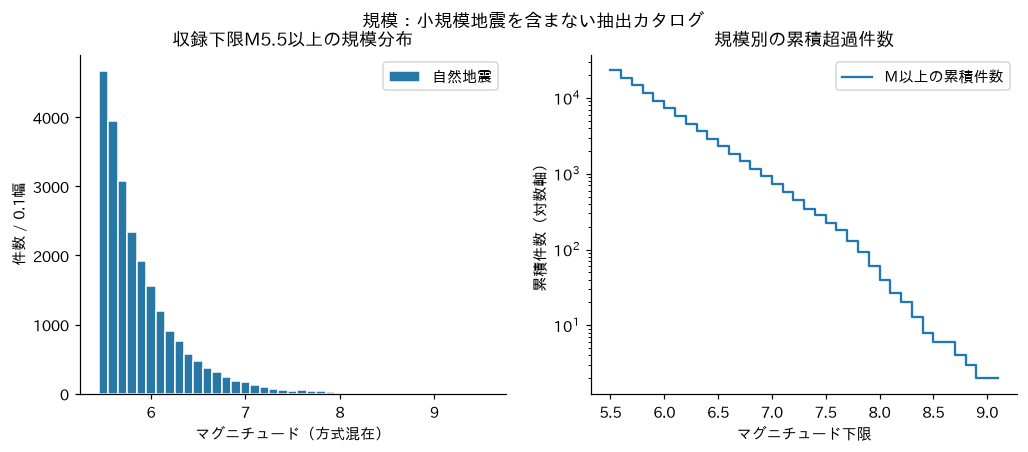

In [10]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].hist(eq['Magnitude'],bins=np.arange(5.45,9.56,.1),color='#2878a5',edgecolor='white',label='自然地震')
axes[0].set(title='収録下限M5.5以上の規模分布',xlabel='マグニチュード（方式混在）',ylabel='件数 / 0.1幅')
axes[0].legend()
cutoffs = np.arange(5.5,9.11,.1)
axes[1].step(cutoffs,[(eq['Magnitude'] >= c-1e-8).sum() for c in cutoffs],where='post',label='M以上の累積件数')
axes[1].set(yscale='log',title='規模別の累積超過件数',xlabel='マグニチュード下限',ylabel='累積件数（対数軸）')
axes[1].legend()
fig.suptitle('規模：小規模地震を含まない抽出カタログ')
show_figure(fig,'magnitude','左：自然地震件数、右：規模下限以上の累積件数。フィット・予測なし')


図表監査情報: {"title": "深さ：歪んだ分布と離散的な集中", "xlabel": "震源深さ (km); 震源深さ (km)", "ylabel": "件数 / 20 km幅; 件数 / 1 km幅", "legend": "青：深さ件数、橙：70 km、緑：300 km。負深さ3件は表で提示", "missing_glyphs": [], "id": "depth", "warnings": []}


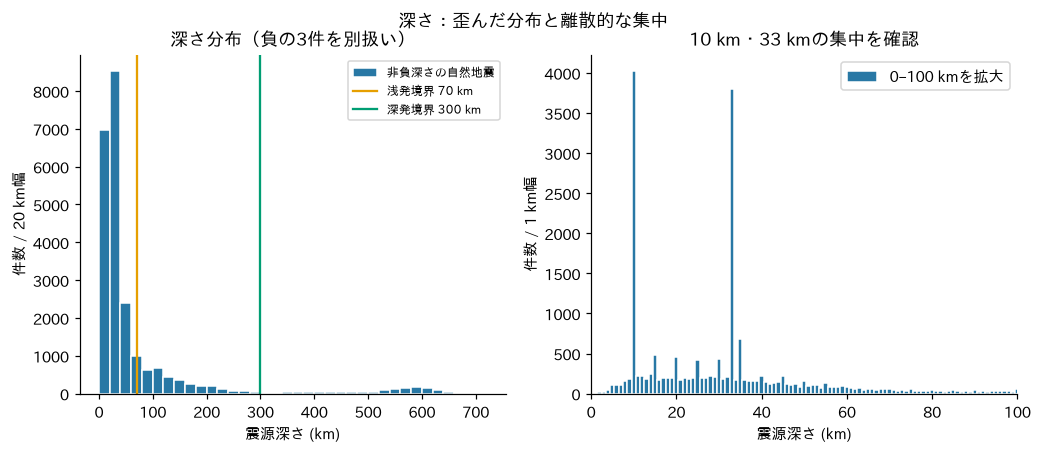

In [11]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
positive = eq.loc[eq['Depth'].ge(0)]
axes[0].hist(positive['Depth'], bins=np.arange(0,721,20),color='#2878a5',edgecolor='white',label='非負深さの自然地震')
axes[0].axvline(70,color='#e69f00',label='浅発境界 70 km')
axes[0].axvline(300,color='#009e73',label='深発境界 300 km')
axes[0].set(title='深さ分布（負の3件を別扱い）',xlabel='震源深さ (km)',ylabel='件数 / 20 km幅')
axes[0].legend(fontsize=8)
axes[1].hist(positive['Depth'],bins=np.arange(-.5,100.6,1),color='#2878a5',edgecolor='white',label='0–100 kmを拡大')
axes[1].set(xlim=(0,100),title='10 km・33 kmの集中を確認',xlabel='震源深さ (km)',ylabel='件数 / 1 km幅')
axes[1].legend()
fig.suptitle('深さ：歪んだ分布と離散的な集中')
show_figure(fig,'depth','青：深さ件数、橙：70 km、緑：300 km。負深さ3件は表で提示')


図表監査情報: {"title": "年別収録件数：規模下限別（1965–2016）", "xlabel": "発生年（UTCとして正規化）", "ylabel": "自然地震の収録件数 / 暦年", "legend": "線の凡例は規模下限。真の発生率・予測ではなく暦年別カタログ件数", "missing_glyphs": [], "id": "annual", "warnings": []}


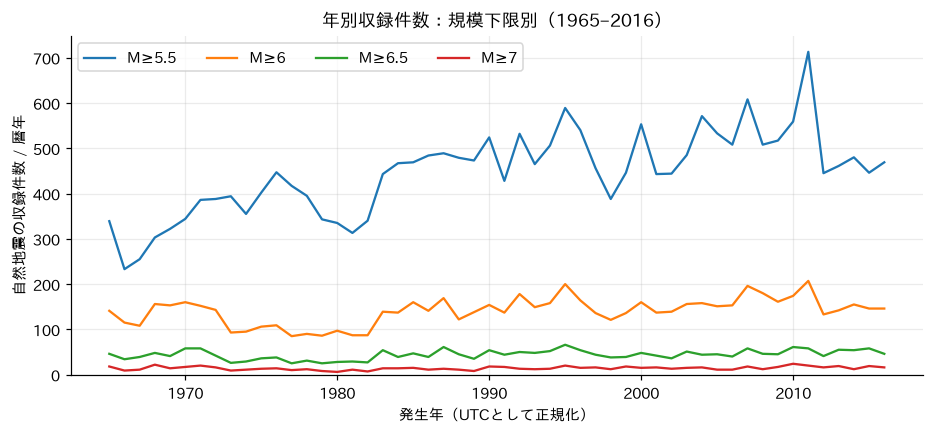

In [12]:
fig, ax = plt.subplots(figsize=(10,4))
for column in annual:
    ax.plot(annual.index, annual[column], label=column,linewidth=1.5)
ax.set(title='年別収録件数：規模下限別（1965–2016）',xlabel='発生年（UTCとして正規化）',ylabel='自然地震の収録件数 / 暦年')
ax.set_ylim(bottom=0)
ax.legend(ncol=4)
ax.grid(alpha=.25)
show_figure(fig,'annual','線の凡例は規模下限。真の発生率・予測ではなく暦年別カタログ件数')


In [13]:
with phase('execution', '地理背景・等面積集計'):
    basemap_url = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_land.geojson'
    basemap_path = data_dir / 'ne_110m_land.geojson'
    if not basemap_path.exists():
        response = requests.get(basemap_url, timeout=45)
        response.raise_for_status()
        basemap_path.write_bytes(response.content)
    land = json.loads(basemap_path.read_text(encoding='utf-8'))
    print('地理背景はNatural Earth 1:110m land（地震の追加データではない）:',basemap_url)
    print('背景SHA256:',hashlib.sha256(basemap_path.read_bytes()).hexdigest())
    def rings_of_land():
        for feature in land['features']:
            geom = feature['geometry']
            polygons = geom['coordinates'] if geom['type']=='MultiPolygon' else [geom['coordinates']]
            for polygon in polygons:
                yield np.asarray(polygon[0],dtype=float)
    def draw_coast(ax, projected=False):
        for ring in rings_of_land():
            for segment in np.split(ring,np.where(np.abs(np.diff(ring[:,0]))>180)[0]+1):
                if len(segment)>1:
                    x = np.deg2rad(segment[:,0]) if projected else segment[:,0]
                    y = np.deg2rad(segment[:,1]) if projected else np.sin(np.deg2rad(segment[:,1]))
                    ax.plot(x,y,color='#555555',linewidth=.45,zorder=2)
    longitude_edges = np.arange(-180,181,10)
    sin_lat_edges = np.linspace(-1,1,19)
    spatial_counts,_,_ = np.histogram2d(eq['Longitude'], np.sin(np.deg2rad(eq['Latitude'])),bins=[longitude_edges,sin_lat_edges])
    assert int(spatial_counts.sum()) == len(eq)
    grid_area_km2 = 6371.0088**2 * np.deg2rad(10) * (2/18)
    print('等面積セル:',spatial_counts.size,'; セル面積km²:',grid_area_km2,'; 集計合計:',int(spatial_counts.sum()))
    hottest = np.argsort(spatial_counts.ravel())[-10:][::-1]
    geographic_table = pd.DataFrame([{'経度範囲':f'{longitude_edges[i]}〜{longitude_edges[i+1]}','緯度範囲':f'{np.rad2deg(np.arcsin(sin_lat_edges[j])):.1f}〜{np.rad2deg(np.arcsin(sin_lat_edges[j+1])):.1f}','件数':int(spatial_counts[i,j])} for i,j in [np.unravel_index(k,spatial_counts.shape) for k in hottest]])
    display(geographic_table)

    display({'text/plain':f'集計合計: {int(spatial_counts.sum())}'},raw=True)


地理背景はNatural Earth 1:110m land（地震の追加データではない）: https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_land.geojson
背景SHA256: 9e0729ee253ca7d7a5c4ae9395fb1902264c5377c52e224d13dd85010e2835d9
等面積セル: 648 ; セル面積km²: 787138.705205049 ; 集計合計: 23232


,経度範囲,緯度範囲,件数
0,-180〜-170,-19.5〜-12.8,977
1,-180〜-170,-26.4〜-19.5,892
2,120〜130,0.0〜6.4,873
3,140〜150,33.7〜41.8,792
4,150〜160,-6.4〜0.0,755
5,160〜170,-19.5〜-12.8,710
6,-180〜-170,-33.7〜-26.4,666
7,160〜170,-12.8〜-6.4,588
8,140〜150,41.8〜51.1,560
9,140〜150,-6.4〜0.0,534


集計合計: 23232

図表監査情報: {"title": "震源の分布：Mollweide等面積投影、点の色は深さ; ", "xlabel": "経度（中央子午線0°）; 震源深さ (km)、非負の値のみ色付け", "ylabel": "緯度", "legend": "点：自然地震、色：深さ0–700 km、赤×：負深さ。点の重なりは件数密度そのものではない", "missing_glyphs": [], "id": "world_points", "warnings": []}


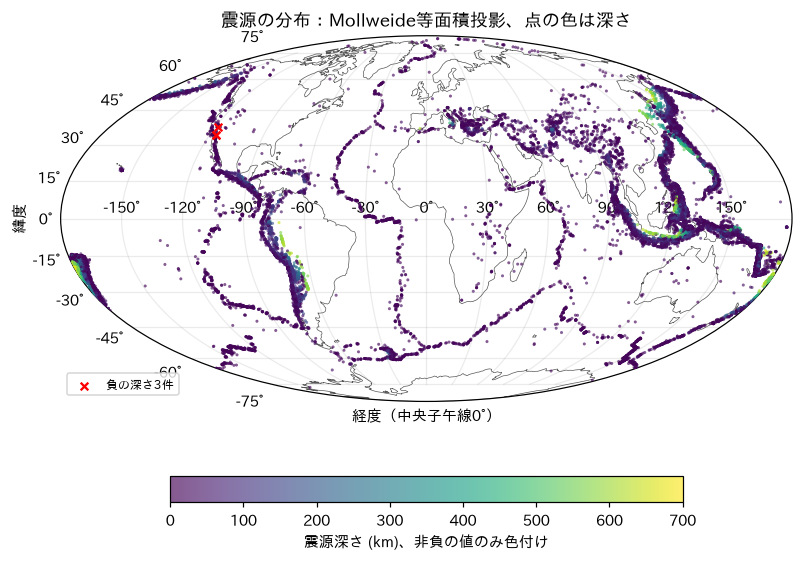

In [14]:
fig = plt.figure(figsize=(11,5.5))
ax = fig.add_subplot(111,projection='mollweide')
draw_coast(ax,projected=True)
points = ax.scatter(np.deg2rad(positive['Longitude']),np.deg2rad(positive['Latitude']),c=positive['Depth'],s=4,cmap='viridis',norm=colors.Normalize(0,700),alpha=.65,linewidths=0,zorder=3)
negative = eq.loc[eq['Depth'].lt(0)]
ax.scatter(np.deg2rad(negative['Longitude']),np.deg2rad(negative['Latitude']),marker='x',s=25,color='red',label='負の深さ3件',zorder=4)
ax.grid(alpha=.25)
ax.set(title='震源の分布：Mollweide等面積投影、点の色は深さ',xlabel='経度（中央子午線0°）',ylabel='緯度')
ax.legend(loc='lower left',fontsize=8)
cbar = fig.colorbar(points,ax=ax,orientation='horizontal',pad=.16,fraction=.055)
cbar.set_label('震源深さ (km)、非負の値のみ色付け')
show_figure(fig,'world_points','点：自然地震、色：深さ0–700 km、赤×：負深さ。点の重なりは件数密度そのものではない')


図表監査情報: {"title": "同じ面積の区画に収録された地震件数（ゼロは白）; ", "xlabel": "経度（10°幅）", "ylabel": "緯度：縦座標はsin(緯度)、等面積; 1965–2016の件数 / 等面積セル（対数色尺度）", "legend": "色：等面積セルの全期間収録件数（対数）、白：0件。人口・被害・将来危険度ではない", "missing_glyphs": [], "id": "world_equal_area", "warnings": []}


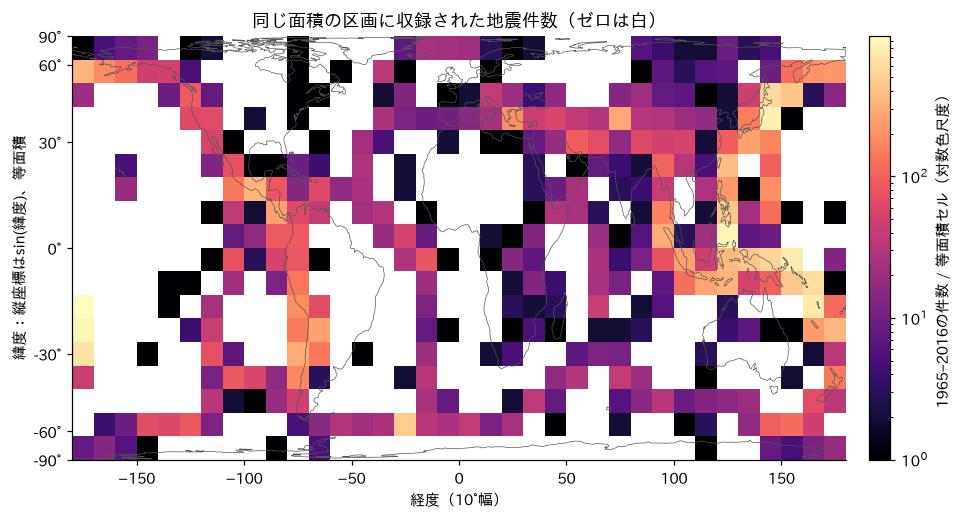

In [15]:
fig, ax = plt.subplots(figsize=(11,5))
mesh = ax.pcolormesh(longitude_edges,sin_lat_edges,np.ma.masked_equal(spatial_counts.T,0),cmap='magma',norm=colors.LogNorm(vmin=1,vmax=spatial_counts.max()),shading='flat')
draw_coast(ax)
lat_ticks = np.array([-90,-60,-30,0,30,60,90])
ax.set_yticks(np.sin(np.deg2rad(lat_ticks)),labels=[f'{x}°' for x in lat_ticks])
ax.set(xlim=(-180,180),ylim=(-1,1),title='同じ面積の区画に収録された地震件数（ゼロは白）',xlabel='経度（10°幅）',ylabel='緯度：縦座標はsin(緯度)、等面積')
cbar = fig.colorbar(mesh,ax=ax,pad=.025)
cbar.set_label('1965–2016の件数 / 等面積セル（対数色尺度）')
show_figure(fig,'world_equal_area','色：等面積セルの全期間収録件数（対数）、白：0件。人口・被害・将来危険度ではない')


## 反復依頼履歴

### 反復1（原文）
規模の収録下限と測定方式の混在が時間変化・浅発地震割合に与える影響を調べてください。M5.5・6.0・6.5・7.0以上と全方式・MW系に限定した場合を比較し、初期1965–1980年と後期1999–2016年の暦年平均件数比を計算してください。カタログ完全性や短期予知を保証する指標とは解釈しないでください。

選定理由: 初回結果の年別増加解釈と浅発割合を、観測・測定方式の変化に対して再点検する。許容相対差20%は事前に置く記述的基準。

In [16]:
iteration_history = []
with phase('execution', '反復1: 規模下限・方式別の感度分析'):
    request = '規模の収録下限と測定方式の混在が時間変化・浅発地震割合に与える影響を調べてください。M5.5・6.0・6.5・7.0以上と全方式・MW系に限定した場合を比較し、初期1965–1980年と後期1999–2016年の暦年平均件数比を計算してください。カタログ完全性や短期予知を保証する指標とは解釈しないでください。'
    iteration_history.append({'iteration':1,'request':request,'reason':'初回では年別件数増加とMB/MS/MW混在があり、検出・方式変更と真の発生変化を区別する必要がある。'})
    def selected(cut, kind):
        chosen = eq.loc[eq['Magnitude'].ge(cut)]
        if kind == 'MW系':
            chosen = chosen.loc[chosen['Magnitude Type'].fillna('').str.startswith('MW')]
        return chosen
    def era_ratio(cut, kind):
        chosen = selected(cut,kind)
        first = chosen['year'].between(1965,1980).sum()/16
        last = chosen['year'].between(1999,2016).sum()/18
        if first == 0:
            raise ValueError('初期件数ゼロで比率定義不能')
        return last / first
    def shallow_share(cut,kind):
        chosen = selected(cut,kind)
        chosen = chosen.loc[chosen['Depth'].ge(0)]
        return chosen['Depth'].le(70).mean()
    plan1 = sensitivity.SensitivityPlan(parameter_grid={'cut':[5.5,6.0,6.5,7.0],'kind':['全方式','MW系']},max_runs=8)
    ratio_report = sensitivity.run_sensitivity(plan1,era_ratio,stability_tolerance=.20)
    shallow_report = sensitivity.run_sensitivity(plan1,shallow_share,stability_tolerance=.20)
    print('年平均件数比の感度分析:',json.dumps(asdict(ratio_report),ensure_ascii=False))
    print('浅発割合の感度分析:',json.dumps(asdict(shallow_report),ensure_ascii=False))
    iteration1_table = pd.DataFrame([{'下限M':cut,'方式':kind,'n':len(selected(cut,kind)),'初期件数/年':selected(cut,kind)['year'].between(1965,1980).sum()/16,'後期件数/年':selected(cut,kind)['year'].between(1999,2016).sum()/18,'後期/初期':era_ratio(cut,kind),'浅発割合':shallow_share(cut,kind)} for cut in [5.5,6,6.5,7] for kind in ['全方式','MW系']])
    display(iteration1_table)
    mode_share = pd.crosstab(pd.cut(eq['year'],[1964,1980,1998,2016],labels=['1965–1980','1981–1998','1999–2016']),eq['Magnitude Type'],normalize='index')*100
    print('時期別規模方式割合 (%)'); display(mode_share.round(2))
    print('感度stableは許容20%の操作的指標であり、統計的有意性・Mc推定・完全性保証ではない。MW系限定にも測定方式採用時期による選択バイアスがある。')
    iteration_history[-1].update({'results':asdict(ratio_report),'shallow_results':asdict(shallow_report),'limits':'露出を暦年で仮定。方式限定は独立検証ではない。M5.5未満がないため検出限界McをこのCSVのみから推定しない。'})

    display({'text/plain':json.dumps(asdict(ratio_report),ensure_ascii=False)},raw=True)


年平均件数比の感度分析: {"results": [{"specification": {"cut": 5.5, "kind": "全方式"}, "value": 1.4436196535878403}, {"specification": {"cut": 5.5, "kind": "MW系"}, "value": 2.935912314635719}, {"specification": {"cut": 6.0, "kind": "全方式"}, "value": 1.3316863713899183}, {"specification": {"cut": 6.0, "kind": "MW系"}, "value": 2.1416275430359937}, {"specification": {"cut": 6.5, "kind": "全方式"}, "value": 1.2759381898454745}, {"specification": {"cut": 6.5, "kind": "MW系"}, "value": 2.0564564564564565}, {"specification": {"cut": 7.0, "kind": "全方式"}, "value": 1.2190476190476192}, {"specification": {"cut": 7.0, "kind": "MW系"}, "value": 1.9541984732824427}], "baseline_value": 1.4436196535878403, "stable": false, "max_relative_deviation": 1.0337159495848307}
浅発割合の感度分析: {"results": [{"specification": {"cut": 5.5, "kind": "全方式"}, "value": 0.7969348659003831}, {"specification": {"cut": 5.5, "kind": "MW系"}, "value": 0.7917786738351255}, {"specification": {"cut": 6.0, "kind": "全方式"}, "value": 0.8023303632625086}, {"

,下限M,方式,n,初期件数/年,後期件数/年,後期/初期,浅発割合
0,5.5,全方式,23232,353.6250,510.500000,1.443620,0.796935
1,5.5,MW系,17857,161.5625,474.333333,2.935912,0.791779
2,6.0,全方式,7296,118.0625,157.222222,1.331686,0.802330
3,6.0,MW系,6184,71.0000,152.055556,2.141628,0.790393
4,6.5,全方式,2297,37.7500,48.166667,1.275938,0.792247
5,6.5,MW系,1987,23.1250,47.555556,2.056456,0.766868
6,7.0,全方式,738,13.1250,16.000000,1.219048,0.780190
7,7.0,MW系,642,8.1875,16.000000,1.954198,0.748830


Magnitude Type,MB,MD,MH,ML,MS,MW,MWB,MWC,MWR,MWW
year,,,,,,,,,,
1965–1980,34.36,0.02,0.04,0.28,19.62,45.60,0.00,0.09,0.00,0.00
1981–1998,12.47,0.04,0.04,0.42,6.70,61.01,5.73,13.60,0.00,0.00
1999–2016,6.58,0.02,0.00,0.15,0.33,0.30,21.53,49.22,0.28,21.58


{"results": [{"specification": {"cut": 5.5, "kind": "全方式"}, "value": 1.4436196535878403}, {"specification": {"cut": 5.5, "kind": "MW系"}, "value": 2.935912314635719}, {"specification": {"cut": 6.0, "kind": "全方式"}, "value": 1.3316863713899183}, {"specification": {"cut": 6.0, "kind": "MW系"}, "value": 2.1416275430359937}, {"specification": {"cut": 6.5, "kind": "全方式"}, "value": 1.2759381898454745}, {"specification": {"cut": 6.5, "kind": "MW系"}, "value": 2.0564564564564565}, {"specification": {"cut": 7.0, "kind": "全方式"}, "value": 1.2190476190476192}, {"specification": {"cut": 7.0, "kind": "MW系"}, "value": 1.9541984732824427}], "baseline_value": 1.4436196535878403, "stable": false, "max_relative_deviation": 1.0337159495848307}

### 反復2（原文）
深さ10 kmと33 kmへの集中、および負の深さ3件が「浅い地震が多数」という結論に実質的な影響を与えるか確認してください。負深さの保持・除外、10/33 kmの保持・除外、全期間と1999–2016年を比較し、中央値と70 km以下の割合を示してください。集中値を誤記や固定深さと断定せず、除外は感度分析だけにしてください。

選定理由: 反復1では浅発優勢が維持されたが、深さ集中値と負深さの影響は未検証だった。

In [17]:
with phase('execution', '反復2: 深さ集中値・負深さの感度分析'):
    iteration_history.append({'iteration':2,'request':'深さ10 kmと33 kmへの集中、および負の深さ3件が「浅い地震が多数」という結論に実質的な影響を与えるか確認してください。負深さの保持・除外、10/33 kmの保持・除外、全期間と1999–2016年を比較し、中央値と70 km以下の割合を示してください。集中値を誤記や固定深さと断定せず、除外は感度分析だけにしてください。','reason':'反復1で浅発優勢は方式・規模下限に安定だったが、初回で10/33 km集中が大きく、深さの中央値を実際の物理分布として読む危険が残る。'})
    def depth_selected(negative_policy, spike_policy, period):
        chosen = eq.copy()
        if negative_policy == '除外':
            chosen = chosen.loc[chosen['Depth'].ge(0)]
        if spike_policy == '除外':
            chosen = chosen.loc[~chosen['Depth'].isin([10.,33.])]
        if period == '1999–2016':
            chosen = chosen.loc[chosen['year'].between(1999,2016)]
        return chosen
    def depth_shallow(negative_policy,spike_policy,period):
        chosen = depth_selected(negative_policy,spike_policy,period)
        return chosen['Depth'].between(0,70).mean()
    plan2 = sensitivity.SensitivityPlan(parameter_grid={'negative_policy':['保持','除外'],'spike_policy':['保持','除外'],'period':['全期間','1999–2016']},max_runs=8)
    depth_report = sensitivity.run_sensitivity(plan2,depth_shallow,stability_tolerance=.20)
    depth_sensitivity_table = pd.DataFrame([{'負深さ':neg,'10/33km':spike,'期間':period,'n':len(depth_selected(neg,spike,period)),'深さ中央値':float(depth_selected(neg,spike,period)['Depth'].median()),'0–70km割合':depth_shallow(neg,spike,period)} for neg in ['保持','除外'] for spike in ['保持','除外'] for period in ['全期間','1999–2016']])
    display(depth_sensitivity_table)
    print('深さの感度分析:',json.dumps(asdict(depth_report),ensure_ascii=False))
    spike_table = eq.groupby(pd.cut(eq['year'],[1964,1980,1998,2016],labels=['1965–1980','1981–1998','1999–2016']),observed=True)['Depth'].agg(n='size',at_10=lambda s:s.eq(10).sum(),at_33=lambda s:s.eq(33).sum(),error_missing=lambda s:raw.loc[s.index,'Depth Error'].isna().sum())
    spike_table['10/33km_pct'] = (spike_table.at_10+spike_table.at_33)/spike_table.n*100
    display(spike_table)
    print('10km集中:',int(eq['Depth'].eq(10).sum()),'; 33km集中:',int(eq['Depth'].eq(33).sum()),'; 両者割合:',float(eq['Depth'].isin([10,33]).mean()*100))
    print('負深さを誤記と断定しない。基準面・解法・固定値の詳細は未確認。10/33kmを除いた標本は別の選択標本であり、補正済み分布ではない。深さ誤差の欠損は補完しない。')
    iteration_history[-1].update({'results':asdict(depth_report),'limits':'固定・丸め・実測の区別はCSVだけでは不可能。中央値33kmを特別な物理深度と解釈できない。'})

    display({'text/plain':json.dumps(asdict(depth_report),ensure_ascii=False)},raw=True)


深さの感度分析: {"results": [{"specification": {"negative_policy": "保持", "spike_policy": "保持", "period": "全期間"}, "value": 0.796831955922865}, {"specification": {"negative_policy": "保持", "spike_policy": "保持", "period": "1999–2016"}, "value": 0.8171727064968984}, {"specification": {"negative_policy": "保持", "spike_policy": "除外", "period": "全期間"}, "value": 0.6979779882262606}, {"specification": {"negative_policy": "保持", "spike_policy": "除外", "period": "1999–2016"}, "value": 0.721300597213006}, {"specification": {"negative_policy": "除外", "spike_policy": "保持", "period": "全期間"}, "value": 0.7969348659003831}, {"specification": {"negative_policy": "除外", "spike_policy": "保持", "period": "1999–2016"}, "value": 0.8171727064968984}, {"specification": {"negative_policy": "除外", "spike_policy": "除外", "period": "全期間"}, "value": 0.698112}, {"specification": {"negative_policy": "除外", "spike_policy": "除外", "period": "1999–2016"}, "value": 0.721300597213006}], "baseline_value": 0.796831955922865, "stable": true, "

,負深さ,10/33km,期間,n,深さ中央値,0–70km割合
0,保持,保持,全期間,23232,33.0,0.796832
1,保持,保持,1999–2016,9189,26.4,0.817173
2,保持,除外,全期間,15628,39.1,0.697978
3,保持,除外,1999–2016,6028,35.0,0.721301
4,除外,保持,全期間,23229,33.0,0.796935
5,除外,保持,1999–2016,9189,26.4,0.817173
6,除外,除外,全期間,15625,39.2,0.698112
7,除外,除外,1999–2016,6028,35.0,0.721301


,n,at_10,at_33,error_missing,10/33km_pct
year,,,,,
1965–1980,5658,303,1053,5638,23.966066
1981–1998,8385,1282,1805,6787,36.815742
1999–2016,9189,2326,835,6358,34.399826


{"results": [{"specification": {"negative_policy": "保持", "spike_policy": "保持", "period": "全期間"}, "value": 0.796831955922865}, {"specification": {"negative_policy": "保持", "spike_policy": "保持", "period": "1999–2016"}, "value": 0.8171727064968984}, {"specification": {"negative_policy": "保持", "spike_policy": "除外", "period": "全期間"}, "value": 0.6979779882262606}, {"specification": {"negative_policy": "保持", "spike_policy": "除外", "period": "1999–2016"}, "value": 0.721300597213006}, {"specification": {"negative_policy": "除外", "spike_policy": "保持", "period": "全期間"}, "value": 0.7969348659003831}, {"specification": {"negative_policy": "除外", "spike_policy": "保持", "period": "1999–2016"}, "value": 0.8171727064968984}, {"specification": {"negative_policy": "除外", "spike_policy": "除外", "period": "全期間"}, "value": 0.698112}, {"specification": {"negative_policy": "除外", "spike_policy": "除外", "period": "1999–2016"}, "value": 0.721300597213006}], "baseline_value": 0.796831955922865, "stable": true, "max_relat

### 反復3（原文）
地理的な集中が等面積格子の幅・経度の起点・規模下限に左右されるか確認してください。また最多件数の2011年について、日本周辺の経緯度矩形とそれ以外を月別に分け、年別ピークを世界全体の一様な増加と読めるか検討してください。矩形は国境でも余震判定でもなく、地震発生後の記述分析として扱ってください。

選定理由: 反復2後にも、地理集中の格子依存性と2011年ピークの局地的集中を確認する必要が残った。

In [18]:
with phase('execution', '反復3: 地理格子・2011年集中の検討'):
    iteration_history.append({'iteration':3,'request':'地理的な集中が等面積格子の幅・経度の起点・規模下限に左右されるか確認してください。また最多件数の2011年について、日本周辺の経緯度矩形とそれ以外を月別に分け、年別ピークを世界全体の一様な増加と読めるか検討してください。矩形は国境でも余震判定でもなく、地震発生後の記述分析として扱ってください。','reason':'反復2で浅発優勢は維持された。残る実質的な問題は地図の格子依存性と2011年ピークを世界共通の変化と誤読することである。'})
    def top_tenth_share(step,shift_fraction,cut):
        chosen = eq.loc[eq['Magnitude'].ge(cut)]
        lon = (chosen['Longitude'] + 180 - step*shift_fraction)%360 - 180
        hist,_,_ = np.histogram2d(lon,np.sin(np.deg2rad(chosen['Latitude'])),bins=[np.arange(-180,181,step),np.linspace(-1,1,int(180/step)+1)])
        assert int(hist.sum()) == len(chosen)
        ranked = np.sort(hist.ravel())[::-1]
        cells = len(ranked)*.1
        full = int(cells)
        weight = cells-full
        return (ranked[:full].sum()+weight*ranked[full])/len(chosen)
    plan3 = sensitivity.SensitivityPlan(parameter_grid={'step':[10,20],'shift_fraction':[0,.5],'cut':[5.5,6.5]},max_runs=8)
    geo_report = sensitivity.run_sensitivity(plan3,top_tenth_share,stability_tolerance=.20)
    print('地理集中の感度分析（上位面積10%への件数割合）:',json.dumps(asdict(geo_report),ensure_ascii=False))
    display(pd.DataFrame([{'経度幅_deg':r.specification['step'],'経度起点ずらし幅_deg':r.specification['step']*r.specification['shift_fraction'],'下限M':r.specification['cut'],'上位面積10%の件数割合':r.value} for r in geo_report.results]))
    print('上位面積10%は世界の全等面積セルを件数順に並べ、端のセルは面積比で按分。セル内一様を仮定した格子集計指標で、実際の10%領域を厳密に特定したものではない。')
    japan_box = eq['Longitude'].between(130,150) & eq['Latitude'].between(30,45)
    year2011 = eq.loc[eq['year'].eq(2011)].copy()
    year2011['region'] = np.where(japan_box.loc[year2011.index],'日本周辺矩形','その他')
    monthly2011 = pd.crosstab(year2011['month'],year2011['region']).reindex(range(1,13),fill_value=0)
    annual_box = eq.loc[japan_box].groupby('year').size().reindex(annual.index,fill_value=0)
    annual_outside = annual['M≥5.5']-annual_box
    main2011 = year2011.loc[year2011['Magnitude'].idxmax()]
    window90 = (eq['timestamp'] >= main2011['timestamp']) & (eq['timestamp'] < main2011['timestamp']+pd.Timedelta(days=90)) & japan_box
    peak_metrics = {'2011_total':len(year2011),'2011_japan_box':int(japan_box.loc[year2011.index].sum()),'2011_japan_box_pct':float(japan_box.loc[year2011.index].mean()*100),'2011_March_japan_box':int(monthly2011.loc[3,'日本周辺矩形']),'2011_March_total':int(monthly2011.loc[3].sum()),'reference_2006_2010_world_mean':float(annual.loc[2006:2010,'M≥5.5'].mean()),'reference_2006_2010_box_mean':float(annual_box.loc[2006:2010].mean()),'outside_box_peak_year':int(annual_outside.idxmax()),'outside_box_peak_n':int(annual_outside.max()),'2011_outside_box_n':int(annual_outside.loc[2011]),'main_event_timestamp':str(main2011['timestamp']),'main_event_M':float(main2011['Magnitude']),'post_main_90days_box_n':int(window90.sum())}
    print('2011年ピーク検討:',json.dumps(peak_metrics,ensure_ascii=False))
    display(monthly2011)
    print('矩形の大きさは解析者の操作的選択。余震の独立判定・デクラスタリングはしていない。月ごとの日数も異なるため月別件数を同露出の発生率と呼ばない。')
    iteration_history[-1].update({'results':asdict(geo_report),'peak_results':peak_metrics,'limits':'格子の上位順位は解像度依存。矩形分類は国別・プレート別・余震判定ではない。独立カタログと観測網履歴がないため追加計算だけで完全性は解決しない。'})

    display({'text/plain':json.dumps(peak_metrics,ensure_ascii=False)},raw=True)


地理集中の感度分析（上位面積10%への件数割合）: {"results": [{"specification": {"step": 10, "shift_fraction": 0, "cut": 5.5}, "value": 0.8022813360881542}, {"specification": {"step": 10, "shift_fraction": 0, "cut": 6.5}, "value": 0.8355245973008272}, {"specification": {"step": 10, "shift_fraction": 0.5, "cut": 5.5}, "value": 0.8021005509641874}, {"specification": {"step": 10, "shift_fraction": 0.5, "cut": 6.5}, "value": 0.8215933826730518}, {"specification": {"step": 20, "shift_fraction": 0, "cut": 5.5}, "value": 0.6307937327823692}, {"specification": {"step": 20, "shift_fraction": 0, "cut": 6.5}, "value": 0.6455376578145406}, {"specification": {"step": 20, "shift_fraction": 0.5, "cut": 5.5}, "value": 0.6171573691460055}, {"specification": {"step": 20, "shift_fraction": 0.5, "cut": 6.5}, "value": 0.6371789290378754}], "baseline_value": 0.8022813360881542, "stable": false, "max_relative_deviation": 0.23074694451299987}
上位面積10%は世界の全等面積セルを件数順に並べ、端のセルは面積比で按分。セル内一様を仮定した格子集計指標で、実際の10%領域を厳密に特定したものではない。
2011年ピーク検討:

,経度幅_deg,経度起点ずらし幅_deg,下限M,上位面積10%の件数割合
0,10,0.0,5.5,0.802281
1,10,0.0,6.5,0.835525
2,10,5.0,5.5,0.802101
3,10,5.0,6.5,0.821593
4,20,0.0,5.5,0.630794
5,20,0.0,6.5,0.645538
6,20,10.0,5.5,0.617157
7,20,10.0,6.5,0.637179


region,その他,日本周辺矩形
month,,
1,41,1
2,40,1
3,28,200
4,31,21
5,39,9
6,36,7
7,53,10
8,45,6
9,32,8


{"2011_total": 713, "2011_japan_box": 268, "2011_japan_box_pct": 37.58765778401122, "2011_March_japan_box": 200, "2011_March_total": 228, "reference_2006_2010_world_mean": 540.0, "reference_2006_2010_box_mean": 18.0, "outside_box_peak_year": 2007, "outside_box_peak_n": 588, "2011_outside_box_n": 445, "main_event_timestamp": "2011-03-11 05:46:24+00:00", "main_event_M": 9.1, "post_main_90days_box_n": 223}

図表監査情報: {"title": "2011年の月別収録件数：日本周辺矩形とその他", "xlabel": "2011年の月（UTCとして正規化）", "ylabel": "自然地震の件数 / 暦月", "legend": "橙：日本周辺の操作的矩形、青：その他。事後の記述であり、予知・余震判定ではない", "missing_glyphs": [], "id": "peak2011", "warnings": []}


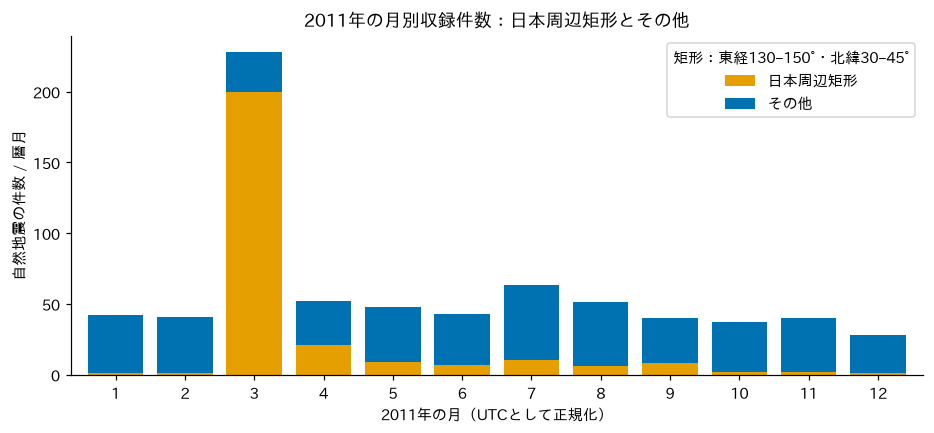

In [19]:
fig, ax = plt.subplots(figsize=(10,4))
monthly2011[['日本周辺矩形','その他']].plot(kind='bar',stacked=True,ax=ax,color=['#e69f00','#0072b2'],width=.8)
ax.set(title='2011年の月別収録件数：日本周辺矩形とその他',xlabel='2011年の月（UTCとして正規化）',ylabel='自然地震の件数 / 暦月')
ax.tick_params(axis='x',rotation=0)
ax.legend(title='矩形：東経130–150°・北緯30–45°')
show_figure(fig,'peak2011','橙：日本周辺の操作的矩形、青：その他。事後の記述であり、予知・余震判定ではない')


## Jupytermind改善候補
候補は下の最小再現セルのログに記録する。分類・再現条件・期待/実際・影響・回避策・関連セル/ログを候補ごとに保存する。元の年別図のU+2265文字欠けはfallbackフォント追加で回避し、最終図表を再実行する。chartメタデータ未記録時の監査漏れは、実描画の警告・ラベルを全図で収集しセルメタデータへ同期して回避する。

これらはJupytermindの描画/監査に限定した候補である。Kaggle SDK互換性、外部文書URLの遷移、Jupyter初期ディレクトリ、filesystem MCP許可範囲の問題は別に記録し、Jupytermind不具合やベンチマークランナー不具合と混同しない。


標準出力streamの根拠認識漏れも最小再現する。根拠指標はtext/plain表示出力にも保存して回避する。稼働中Notebookを同セルから書き換えるとJupyter MCPの結果保存が失われる事象は、MCPとファイル書込みの統合上の問題として別に扱い、制御Notebookから対象Notebookへの書込みを行う。

In [20]:
from ai_data_scientist import insight_engine
with phase('execution', 'Jupytermind改善候補の最小再現'):
    with plt.rc_context({'font.family':['IPAexGothic']}):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            reproduction_png = visualization.render_chart(pd.DataFrame({'x':[1,2]}),kind='hist',x='x',title='日本語 M≥5.5',xlabel='規模',ylabel='件数')
    font_reproduction = [str(w.message) for w in caught if 'Glyph' in str(w.message)]
    print('font_fallback_reproduction:',json.dumps(font_reproduction,ensure_ascii=False))
    print('期待: 日本語と不等号を同時表示。実際: 元のIPAexGothic単独設定でU+2265の欠落警告。回避: DejaVu Sansをfallbackに追加。')
    sample_cell = nbformat.v4.new_code_cell('図表の最小再現',execution_count=1)
    image = visualization.build_image_output(reproduction_png)
    image['execution_count'] = 1
    sample_cell.outputs = [image]
    sample_nb = nbformat.v4.new_notebook(cells=[sample_cell])
    audit_without_metadata = notebook_audit.audit_visual_outputs(sample_nb,(0,))
    print('metadata_absent_audit_findings:',[asdict(f) for f in audit_without_metadata])
    print('期待: chartメタデータ未記録を検出。実際: 空メタデータではmissing_label/metadata指摘なし。回避: 実図のラベルと描画警告を出力metadata→セルmetadataへ同期。')
    improvement_candidates = [
        {'classification':'機能不足疑い（フォントfallback）','reproduction':'日本語描画でIPAexGothic単独・U+2265を使用','expected':'日本語と数式記号を欠落なく表示','actual':font_reproduction,'impact':'年別図の規模下限凡例が読めなくなる','workaround':'font.family=[IPAexGothic,DejaVu Sans]','related_cells':['annual','Jupytermind改善候補の最小再現'],'logs':'font_fallback_reproduction、初回annualのmissing_glyphs=[8805]'},
        {'classification':'監査の検出漏れ疑い','reproduction':'build_image_outputのPNGを持つセルにchartメタデータなしでaudit_visual_outputs','expected':'未記録のglyph/ラベル監査情報を指摘','actual':[asdict(f) for f in audit_without_metadata],'impact':'監査情報がない図も監査合格に見える','workaround':'本Notebookでは実描画からchartメタデータを自前記録し全図を再監査','related_cells':['描画環境・図表監査補助','Jupytermind改善候補の最小再現','最終監査'],'logs':'metadata_absent_audit_findings=[]'}
    ]
    print('改善候補:',json.dumps(improvement_candidates,ensure_ascii=False,indent=2))
    print('切り分け: Kaggle SDKのdataset_view非存在、metadata.info構造、USGS用語URL遷移、Jupyter初期ディレクトリ非存在、filesystem MCP許可ルート差異はJupytermind候補に含めない。ベンチマークランナーの不具合を示す証拠なし。')

    stream_cell = nbformat.v4.new_code_cell('print(23232)',execution_count=1,outputs=[nbformat.v4.new_output('stream',name='stdout',text='23232\n')])
    stream_nb = nbformat.v4.new_notebook(cells=[stream_cell])
    stream_matches = insight_engine._find_evidence_cell(stream_nb,1,'23232') is not None
    print('stream_evidence_reproduction:', {'output_contains_23232':True,'evidence_matches':stream_matches})
    improvement_candidates.append({'classification':'不具合疑い（stream根拠出力の未対応）','reproduction':'print(23232)の実行済みstream出力をrecord_insightが照合する条件','expected':'実行済みstdoutの値も根拠として認識','actual':{'evidence_matches':stream_matches,'original_error':'EvidenceMissingError: 初回記述分析の23232はstdoutのみで一致せず'},'impact':'正しい記述所見を記録できない','workaround':'各根拠指標をdisplayのtext/plain MIME出力にも記録','related_cells':['初回記述分析','日本語所見・反復結果の根拠リンク更新','Jupytermind改善候補の最小再現'],'logs':'stream_evidence_reproduction、照合実装はoutput.dataのみ走査'})
    print('追加改善候補:',json.dumps(improvement_candidates[-1],ensure_ascii=False))


font_fallback_reproduction: ["Glyph 8805 (\\N{GREATER-THAN OR EQUAL TO}) missing from font(s) IPAexGothic."]
期待: 日本語と不等号を同時表示。実際: 元のIPAexGothic単独設定でU+2265の欠落警告。回避: DejaVu Sansをfallbackに追加。
metadata_absent_audit_findings: []
期待: chartメタデータ未記録を検出。実際: 空メタデータではmissing_label/metadata指摘なし。回避: 実図のラベルと描画警告を出力metadata→セルmetadataへ同期。
改善候補: [
  {
    "classification": "機能不足疑い（フォントfallback）",
    "reproduction": "日本語描画でIPAexGothic単独・U+2265を使用",
    "expected": "日本語と数式記号を欠落なく表示",
    "actual": [
      "Glyph 8805 (\\N{GREATER-THAN OR EQUAL TO}) missing from font(s) IPAexGothic."
    ],
    "impact": "年別図の規模下限凡例が読めなくなる",
    "workaround": "font.family=[IPAexGothic,DejaVu Sans]",
    "related_cells": [
      "annual",
      "Jupytermind改善候補の最小再現"
    ],
    "logs": "font_fallback_reproduction、初回annualのmissing_glyphs=[8805]"
  },
  {
    "classification": "監査の検出漏れ疑い",
    "reproduction": "build_image_outputのPNGを持つセルにchartメタデータなしでaudit_visual_outputs",
    "expected": "未記録のglyph/ラベル監査情報を指摘",
    "actua

## 使用したJupytermindモジュール
直接import・呼出ししたものだけを記載する。以下はこのNotebookのコードセルとMCP制御セルからの直接利用。間接依存は含めない。

| モジュール（ai_data_scientist配下） | 関数・クラス | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先固定、単一writerでNotebook書込み |
| language_router | detect_language | 日本語の判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status | run_id・取消確認・実行/書込み・終端状態 |
| ingestion | SourceSpec, ingest | 取得済みCSV読込と行数上限検査 |
| cleaning | clean_dataset | 完全重複検査・除去影響の記録 |
| eda | explore | 型、欠損、カテゴリ、数値概要 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 列定義・出所・確認状態。inferredは別途一覧化 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 全期間露出・完全性・非独立性・記述範囲 |
| data_quality | detect_anomalies | 座標・規模・深さ・ID・日時・種別の意味的検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 規模下限、方式、深さ集中、期間、格子への感度 |
| visualization | render_chart, build_image_output | 日本語フォント初期化、PNG MIME化、最小再現 |
| insight_engine | extract_cited_value, record_insight, _find_evidence_cell（最小再現のみ） | 実セル出力に紐づく日本語所見 |
| notebook_audit | audit_notebook, audit_visual_outputs | visual_audit=Trueで最終監査、監査欠落の再現 |

### 適用しない機能と理由
- mcp_gateway.run_and_record: 呼出し側のMCP clientオブジェクトが本セッションのカーネルへ提供されないため使わず、全分析をホストのJupyter MCP実行セルで直接実行し、セルsource/出力を保存する。間接利用として加算しない。
- dataset_validation.compare_datasets / data_quality.validate_anomalies: 独立照合データが提供・取得されていない。同じCSVの部分集合を独立データ扱いしない。
- anomaly_detectionのz-score: 地震規模・深さの裾は実現象を含むため異常値除去根拠にしない。宣言的意味検査を優先する。
- stats_analysis.correlation、ML、因果・予測: 分布記述に不要。非独立イベント・方式混在に通常の独立性p値や短期予測モデルを当てはめない。
- visualization.record_chart: コード未実行でexecution_countを付ける保存方式を避け、Jupyter MCPで実行した図を保存。Mollweide・等面積格子・対数色尺度はMatplotlibで直接描画する。


## 読み方と残る限界
収録条件M5.5以上はKaggle説明と実測最小値で確認した。一方、地域・年代別の完全性マグニチュードMc、観測網の物理的検出下限、無観測期間はこのカタログから確認できずunknownである。M5.5を普遍的な検出限界とは呼ばない。原典の用語URLはGeoJSON形式ページへ遷移したため、この版の列単位の直接裏付けを得られなかった。km・十進度・通常日時のUTCは慣行からのinferredとして明示した。未知・推定項目はmanifestの出力を参照する。

check_manifestの未解決指摘は「暦年の露出を一様とする仮定」「全地域・全年の完全性仮定」。どちらもassumedのままで、年平均件数比は収録件数の記述に限定する。samplingのn/seed欄は全件・乱数不使用としてn=地震件数、seed=Noneを明示した。独立イベントの仮定はrejectedであり、p値・独立ポアソン信頼区間を示さない。

この分析は短期予知を実施・検証していない。年別・地域別・規模別の集計から「いつ・どこで・どの規模の地震が起きるか」を予知することはできない。長期的な確率評価や発生後の緊急地震速報とも異なる。USGSの予知FAQの取得URL・文書SHA・該当説明を文書確認セルに保存した。


書込み手順: 日本語所見セルはpersist_insights / sync_chart_metadataを定義する。最終監査の前に同じカーネルに接続した別Jupyter MCP制御セルから `persist_insights(); write_nb(sync_chart_metadata)` を呼ぶ。監査終了後に監査結果・phase履歴・終端状態をenqueue_writeでNotebookメタデータへ保存する。この書込みもJupyter MCP経由であり、端末・外部スクリプト・委譲を用いない。

In [21]:
from ai_data_scientist import insight_engine
with phase('execution', '日本語所見・反復結果の根拠リンク更新'):
    def remove_generated(nb):
        nb.cells = [c for c in nb.cells if not c.metadata.get('generated_insight')]
    stored_nb = nbformat.read(handle.notebook_path,as_version=4)
    def cited(source_marker,pattern):
        cell = next(c for c in stored_nb.cells if c.cell_type=='code' and source_marker in c.source)
        output_text = '\n'.join(o.get('text','') if o.output_type=='stream' else str(o.get('data',{}).get('text/plain','')) for o in cell.outputs)
        value = insight_engine.extract_cited_value({'output':output_text},pattern)
        return cell.execution_count,value
    claims = [
        ('初回記述分析',r'"n": (\d+)',f'分析対象は自然地震{len(eq):,}件。元CSV{len(raw):,}件から爆発・Rock Burst計180件を区別し、完全重複除去は0件だった。収録端点は1965年1月2日から2016年12月30日。これは52暦年のカタログであり、観測の連続稼働を証明するものではない。'),
        ('初回記述分析',r'"m_median": ([\d.]+)',f'規模中央値はM{initial_metrics["m_median"]}、最大はM{initial_metrics["m_max"]}。M5.5–6.0未満が{magnitude_table.iloc[0]["割合_pct"]:.1f}%を占める。規模が大きい記録ほど少ないが、M5.5未満は収録されないため小規模地震全体の分布は判断できない。Magnitude Typeの混在にも注意する。'),
        ('初回記述分析',r'"shallow_pct_nonnegative": ([\d.]+)',f'非負深さ{len(eq.loc[eq.Depth.ge(0)]):,}件の中央値は{initial_metrics["depth_median_km"]:.1f} km、0–70 kmは{initial_metrics["shallow_pct_nonnegative"]:.2f}%。中発・深発を含む右裾の長い分布で、平均だけでは代表しにくい。深さ単位kmはUSGS慣行による推定で、この版の直接列辞書は取得できなかった。'),
        ('初回記述分析',r'"depth_33_n": (\d+)',f'深さ33 kmに{initial_metrics["depth_33_n"]:,}件、10 kmに{initial_metrics["depth_10_n"]:,}件が集中する。丸め・固定深さ・実測の区別はこのCSVだけでは不能。中央値33 kmを特別な物理的深さと解釈しない。'),
        ('地理背景・等面積集計',r'集計合計: (\d+)',f'Mollweide等面積図で環太平洋側などに帯状の記録集中が見られる。経度120–180度帯は{int(sector_table.iloc[-1]["件数"]):,}件（{sector_table.iloc[-1]["割合_pct"]:.1f}%）だが、国境・プレート区分ではない。等面積648区画の集計合計は全自然地震と一致した。図の件数は被害・人口曝露・将来危険度ではない。'),
        ('反復1: 規模下限',r'"baseline_value": ([\d.]+)',f'反復1: 後期1999–2016/初期1965–1980の暦年平均件数比は全方式M5.5以上で{ratio_report.baseline_value:.3f}、M7以上で{era_ratio(7,"全方式"):.3f}。方式・下限変更の感度stable={ratio_report.stable}、最大相対偏差={ratio_report.max_relative_deviation:.4f}。浅発割合はstable={shallow_report.stable}、最大相対偏差={shallow_report.max_relative_deviation:.4f}。増加量は仕様依存で、観測網・収録・方式変更を真の地震活動変化から分離できない。'),
        ('反復2: 深さ集中値',r'"baseline_value": ([\d.]+)',f'反復2: 負深さ3件の保持/除外、10/33 km集中値の保持/除外、期間変更でも0–70 kmの割合は{depth_sensitivity_table["0–70km割合"].min()*100:.1f}–{depth_sensitivity_table["0–70km割合"].max()*100:.1f}%で過半数を維持。stable={depth_report.stable}、最大相対偏差={depth_report.max_relative_deviation:.4f}。集中値除外は補正ではなく選択標本の感度分析。全期間中央値は集中値を除くと39 km程度まで動くため精密な代表深さを主張しない。'),
        ('反復3: 地理格子',r'"2011_japan_box": (\d+)',f'反復3: 2011年{peak_metrics["2011_total"]}件のうち、日本周辺矩形に{peak_metrics["2011_japan_box"]}件（{peak_metrics["2011_japan_box_pct"]:.1f}%）。3月の世界228件中200件が同矩形に含まれ、矩形外の最多年は{peak_metrics["outside_box_peak_year"]}年だった。世界一様の増加と読むのは不適切。矩形内を余震と一括判定したのではなく、すべて事後の記述。地理的上位面積10%への集中指標は{min(r.value for r in geo_report.results)*100:.1f}–{max(r.value for r in geo_report.results)*100:.1f}%、stable={geo_report.stable}、最大相対偏差={geo_report.max_relative_deviation:.4f}で、厳密な集中割合は格子解像度依存。')
    ]
    insight_specs = [(text,*cited(marker,pattern)) for marker,pattern,text in claims]
    print('根拠付き日本語所見の計画:',len(claims),'件。引用値は実セル出力から抽出。書込みは別のJupyter MCP制御セルからpersist_insights()で実行。')
    print('反復停止理由: 3回で測定方式・深さ集中・空間集計・局地集中を確認。残る完全性、単位原典、余震独立性は同CSVの計算を増やしても検証不能。価値ある追加分析には独立カタログや観測網履歴が必要。')
    print('反復履歴:',json.dumps(iteration_history,ensure_ascii=False,indent=2))

def persist_insights():
    write_nb(remove_generated)
    for text,count,value in insight_specs:
        with phase('write','根拠付き所見'):
            insight_engine.record_insight(handle,text,count,value,'descriptive',language='ja')
            pm.enqueue_write(handle,lambda nb:nb.cells[-1].metadata.update({'generated_insight':True}))
    def order_insights(nb):
        generated = [c for c in nb.cells if c.metadata.get('generated_insight')]
        others = [c for c in nb.cells if not c.metadata.get('generated_insight')]
        position = next(i for i,c in enumerate(others) if c.metadata.get('role')=='final_audit')
        nb.cells = others[:position]+generated+others[position:]
    write_nb(order_insights)
    print('根拠付き所見の永続化:',len(insight_specs),'件')
def sync_chart_metadata(nb):
    for cell in nb.cells:
        for out in cell.get('outputs',[]):
            if 'image/png' in out.get('data',{}):
                if 'chart' not in out.get('metadata',{}):
                    raise ValueError('実描画metadataがない図表')
                cell.metadata['chart'] = out.metadata['chart']
    nb.metadata['analysis'] = {'run_id':RUN_ID,'retrieval':retrieval,'definition':asdict(definition),'assumptions':asdict(assumptions),'iteration_history':iteration_history,'improvement_candidates':improvement_candidates,'execution_route':'Jupyter MCPのみ','final_replay':'再起動後に全コードセルを上から実行。書込みは別MCP制御セルで同期'}


根拠付き日本語所見の計画: 8 件。引用値は実セル出力から抽出。書込みは別のJupyter MCP制御セルからpersist_insights()で実行。
反復停止理由: 3回で測定方式・深さ集中・空間集計・局地集中を確認。残る完全性、単位原典、余震独立性は同CSVの計算を増やしても検証不能。価値ある追加分析には独立カタログや観測網履歴が必要。
反復履歴: [
  {
    "iteration": 1,
    "request": "規模の収録下限と測定方式の混在が時間変化・浅発地震割合に与える影響を調べてください。M5.5・6.0・6.5・7.0以上と全方式・MW系に限定した場合を比較し、初期1965–1980年と後期1999–2016年の暦年平均件数比を計算してください。カタログ完全性や短期予知を保証する指標とは解釈しないでください。",
    "reason": "初回では年別件数増加とMB/MS/MW混在があり、検出・方式変更と真の発生変化を区別する必要がある。",
    "results": {
      "results": [
        {
          "specification": {
            "cut": 5.5,
            "kind": "全方式"
          },
          "value": 1.4436196535878403
        },
        {
          "specification": {
            "cut": 5.5,
            "kind": "MW系"
          },
          "value": 2.935912314635719
        },
        {
          "specification": {
            "cut": 6.0,
            "kind": "全方式"
          },
          "value": 1.3316863713899183
        },
        {
          "specification": {
            "cut": 6.0,
 

## 最終日本語報告と監査
以下の所見は実行済みセルの引用値とexecution_countを持つ。全コードセルの上からの再実行後、visual_audit=Trueで監査し終端状態を保存する。

分析対象は自然地震23,232件。元CSV23,412件から爆発・Rock Burst計180件を区別し、完全重複除去は0件だった。収録端点は1965年1月2日から2016年12月30日。これは52暦年のカタログであり、観測の連続稼働を証明するものではない。

```evidence
{"execution_count":8,"cited_value":"23232","claim_type":"descriptive"}
```

規模中央値はM5.7、最大はM9.1。M5.5–6.0未満が68.6%を占める。規模が大きい記録ほど少ないが、M5.5未満は収録されないため小規模地震全体の分布は判断できない。Magnitude Typeの混在にも注意する。

```evidence
{"execution_count":8,"cited_value":"5.7","claim_type":"descriptive"}
```

非負深さ23,229件の中央値は33.0 km、0–70 kmは79.69%。中発・深発を含む右裾の長い分布で、平均だけでは代表しにくい。深さ単位kmはUSGS慣行による推定で、この版の直接列辞書は取得できなかった。

```evidence
{"execution_count":8,"cited_value":"79.6934865900383","claim_type":"descriptive"}
```

深さ33 kmに3,693件、10 kmに3,911件が集中する。丸め・固定深さ・実測の区別はこのCSVだけでは不能。中央値33 kmを特別な物理的深さと解釈しない。

```evidence
{"execution_count":8,"cited_value":"3693","claim_type":"descriptive"}
```

Mollweide等面積図で環太平洋側などに帯状の記録集中が見られる。経度120–180度帯は11,114件（47.8%）だが、国境・プレート区分ではない。等面積648区画の集計合計は全自然地震と一致した。図の件数は被害・人口曝露・将来危険度ではない。

```evidence
{"execution_count":13,"cited_value":"23232","claim_type":"descriptive"}
```

反復1: 後期1999–2016/初期1965–1980の暦年平均件数比は全方式M5.5以上で1.444、M7以上で1.219。方式・下限変更の感度stable=False、最大相対偏差=1.0337。浅発割合はstable=True、最大相対偏差=0.0604。増加量は仕様依存で、観測網・収録・方式変更を真の地震活動変化から分離できない。

```evidence
{"execution_count":16,"cited_value":"1.4436196535878403","claim_type":"descriptive"}
```

反復2: 負深さ3件の保持/除外、10/33 km集中値の保持/除外、期間変更でも0–70 kmの割合は69.8–81.7%で過半数を維持。stable=True、最大相対偏差=0.1241。集中値除外は補正ではなく選択標本の感度分析。全期間中央値は集中値を除くと39 km程度まで動くため精密な代表深さを主張しない。

```evidence
{"execution_count":17,"cited_value":"0.796831955922865","claim_type":"descriptive"}
```

反復3: 2011年713件のうち、日本周辺矩形に268件（37.6%）。3月の世界228件中200件が同矩形に含まれ、矩形外の最多年は2007年だった。世界一様の増加と読むのは不適切。矩形内を余震と一括判定したのではなく、すべて事後の記述。地理的上位面積10%への集中指標は61.7–83.6%、stable=False、最大相対偏差=0.2307で、厳密な集中割合は格子解像度依存。

```evidence
{"execution_count":18,"cited_value":"268","claim_type":"descriptive"}
```

In [23]:
with phase('execution', '最終監査'):
    audit = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('notebook_audit:',json.dumps({'ok':audit.ok,**asdict(audit)},ensure_ascii=False,indent=2))
    if not audit.ok:
        raise RuntimeError('Notebook監査に未解決の指摘あり')
    with phase('write', 'manifest・監査結果保存'):
        artifacts = {'retrieval-manifest.json':retrieval,'data-definition-manifest.json':asdict(definition),'analysis-assumptions-manifest.json':asdict(assumptions),'iteration-history.json':iteration_history,'notebook-audit.json':{'ok':audit.ok,**asdict(audit)}}
        for filename,payload in artifacts.items():
            (data_dir / filename).write_text(json.dumps(payload,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
        (data_dir / 'eda-manifest.txt').write_text(str(eda_result),encoding='utf-8')
lifecycle.mark_completed(RUN_ID)
status = asdict(lifecycle.get_run_status(RUN_ID))
with phase('write','終端状態の永続化'):
    (data_dir / 'lifecycle-status.json').write_text(json.dumps(status,ensure_ascii=False,indent=2),encoding='utf-8')
print('lifecycle最終状態:',json.dumps(asdict(lifecycle.get_run_status(RUN_ID)),ensure_ascii=False))
print('全phase履歴:',json.dumps(phase_log,ensure_ascii=False,indent=2))

notebook_audit: {
  "ok": true,
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-38-earthquakes/notebooks/kaggle-v020-kaggle-exp-38-earthquakes.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 22,
  "executed_code_cell_count": 21,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    14,
    15,
    16,
    18,
    19,
    26
  ],
  "insight_cell_count": 8,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 40
    }
  ],
  "visual_findings": []
}
lifecycle最終状態: {"run_id": "v020-exp-38", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-38-earthquakes/notebooks/kaggle-v020-kaggle-exp-38-earthquakes.ipynb", "reason": n